Workbook sheets: ['READ ME', 'Model Inventory', 'Synthetic Audit Data', 'Real Audit Log Template', 'Chart Data', 'Chart Preview', 'Distribution Data']
Using sheet: 'Synthetic Audit Data'
Resolved columns: model='Model name', year='Release year', category='Category (SYNTHETIC)', id='List No.'
Saved: Figure_05_model_counts.png and Figure_05_model_counts.svg


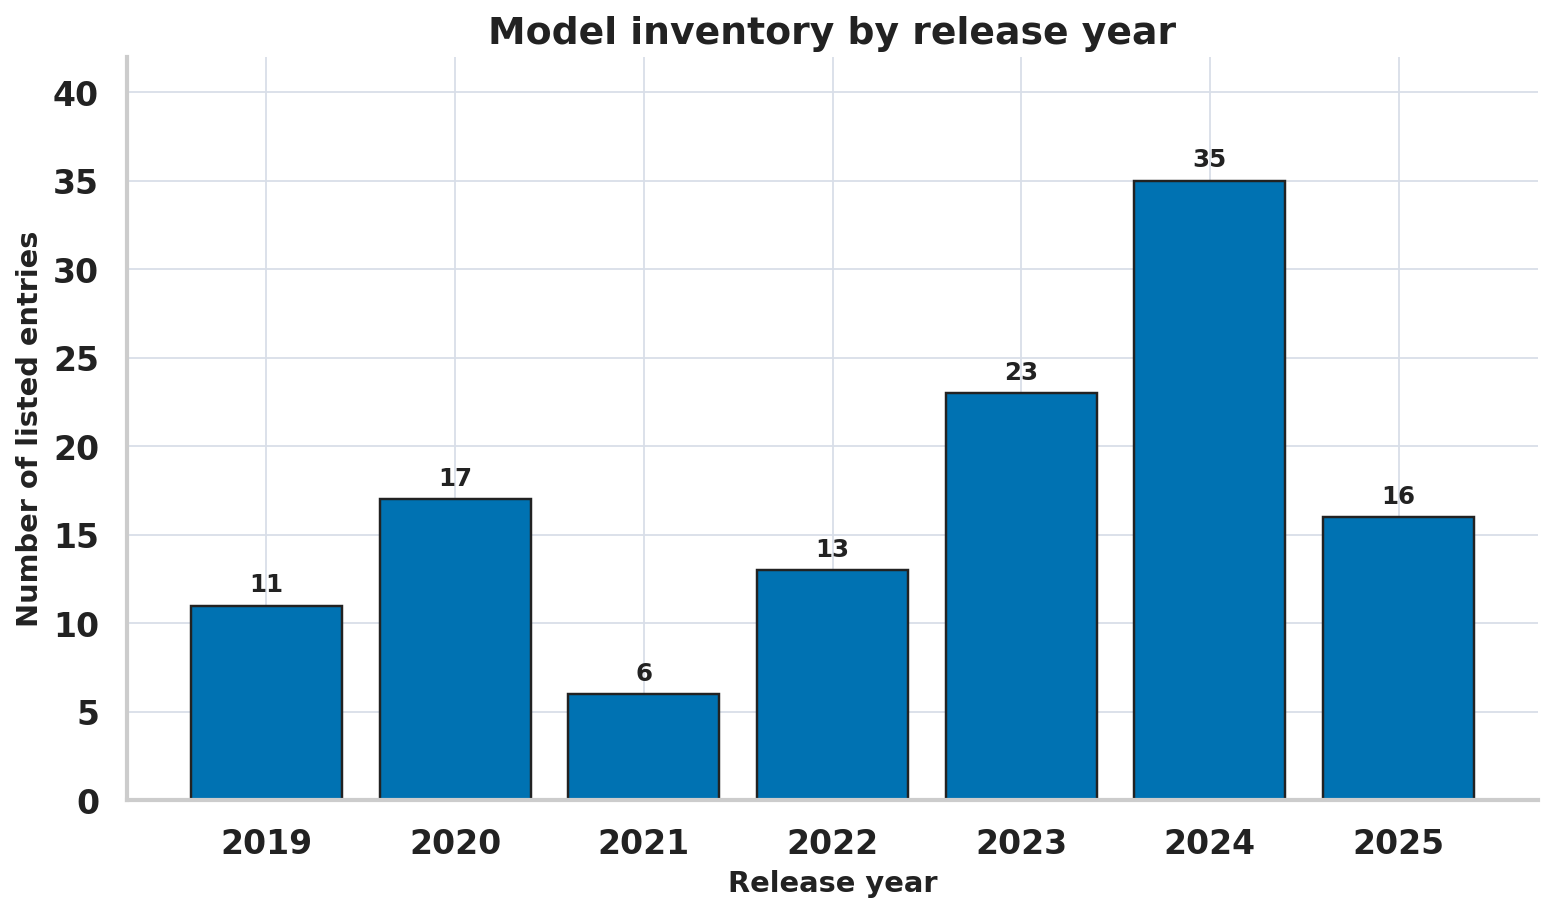

Saved: Figure_10_CTS_distribution.png and Figure_10_CTS_distribution.svg


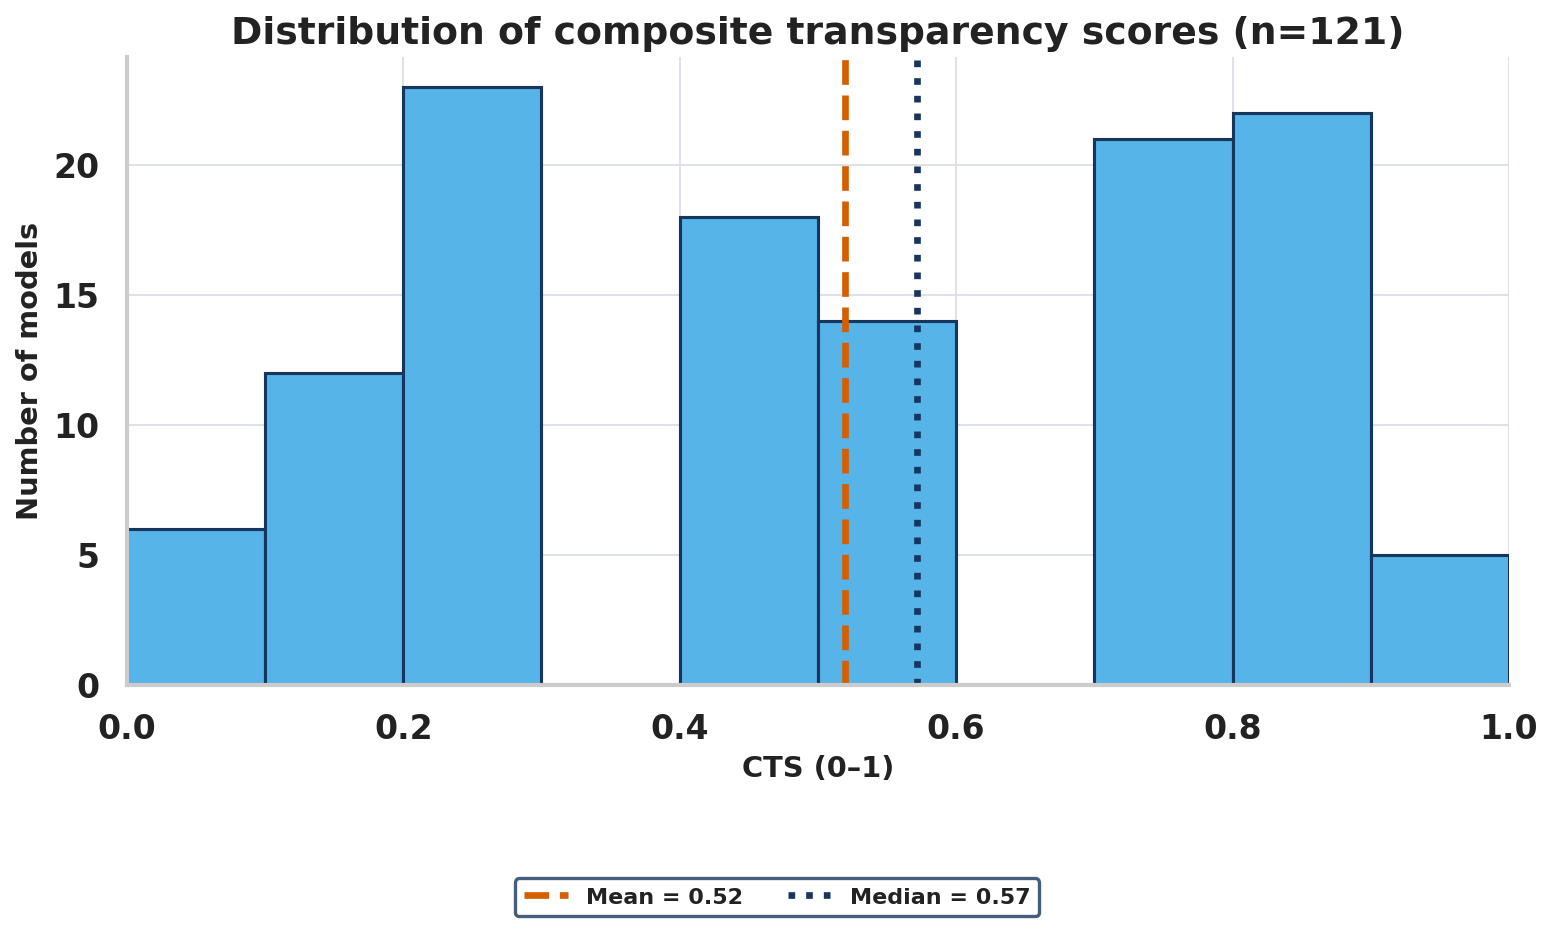

Saved: Figure_11_category_and_year_trends.png and Figure_11_category_and_year_trends.svg


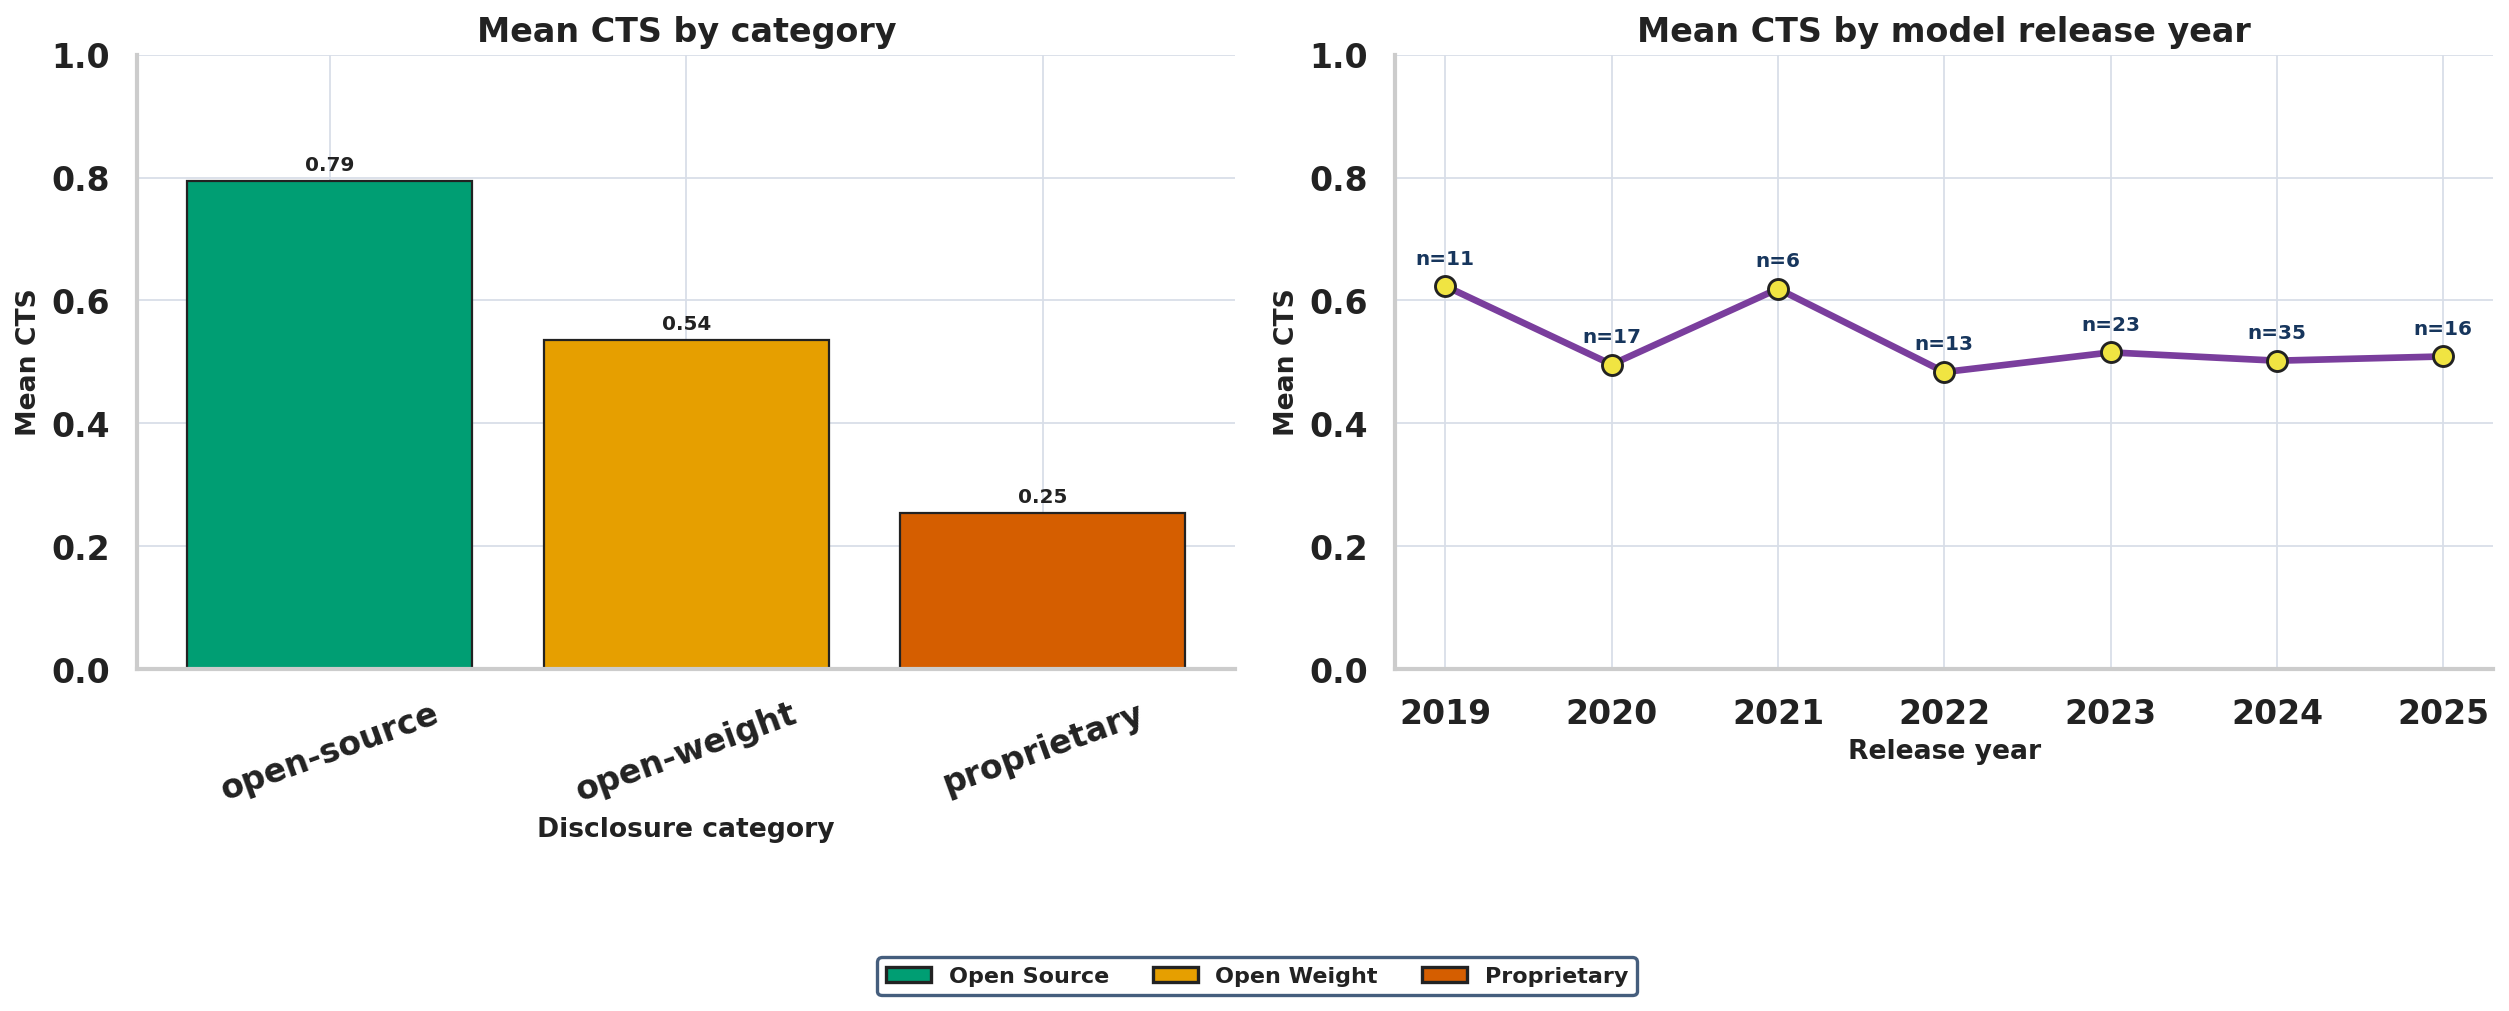

Saved: Figure_12_radar_group_1_001-030.png and Figure_12_radar_group_1_001-030.svg


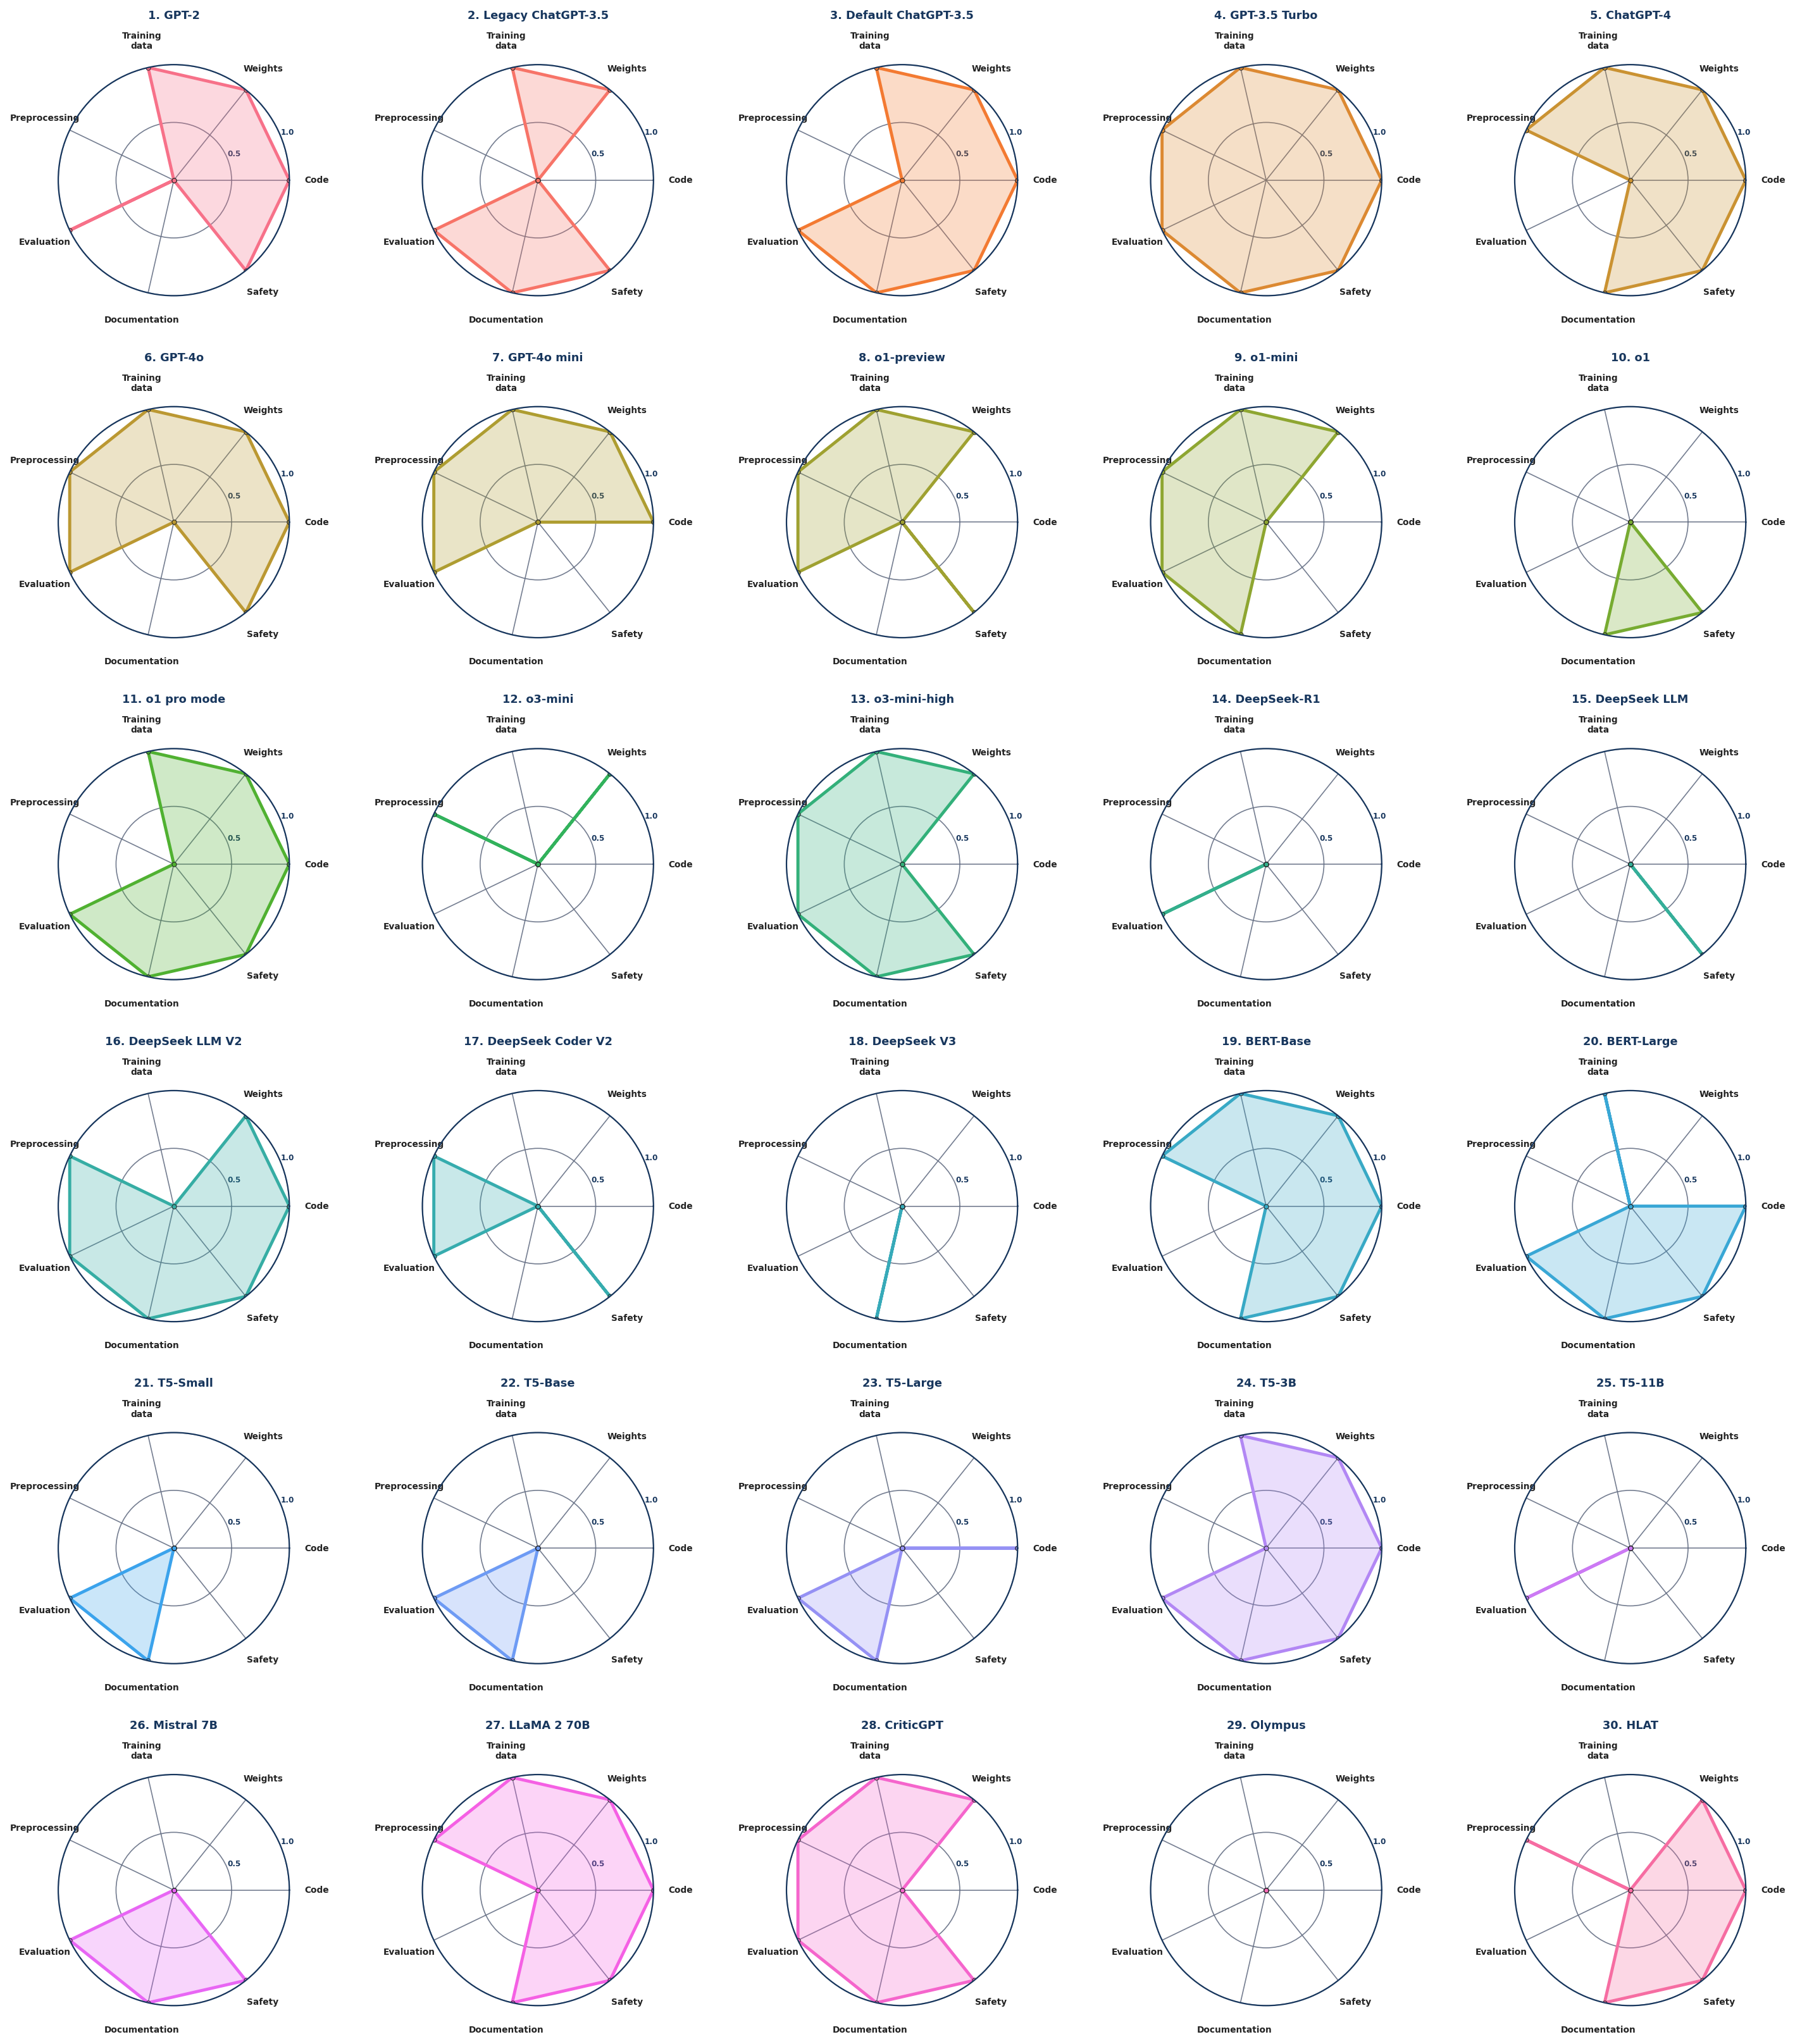

Saved: Figure_12_radar_group_2_031-060.png and Figure_12_radar_group_2_031-060.svg


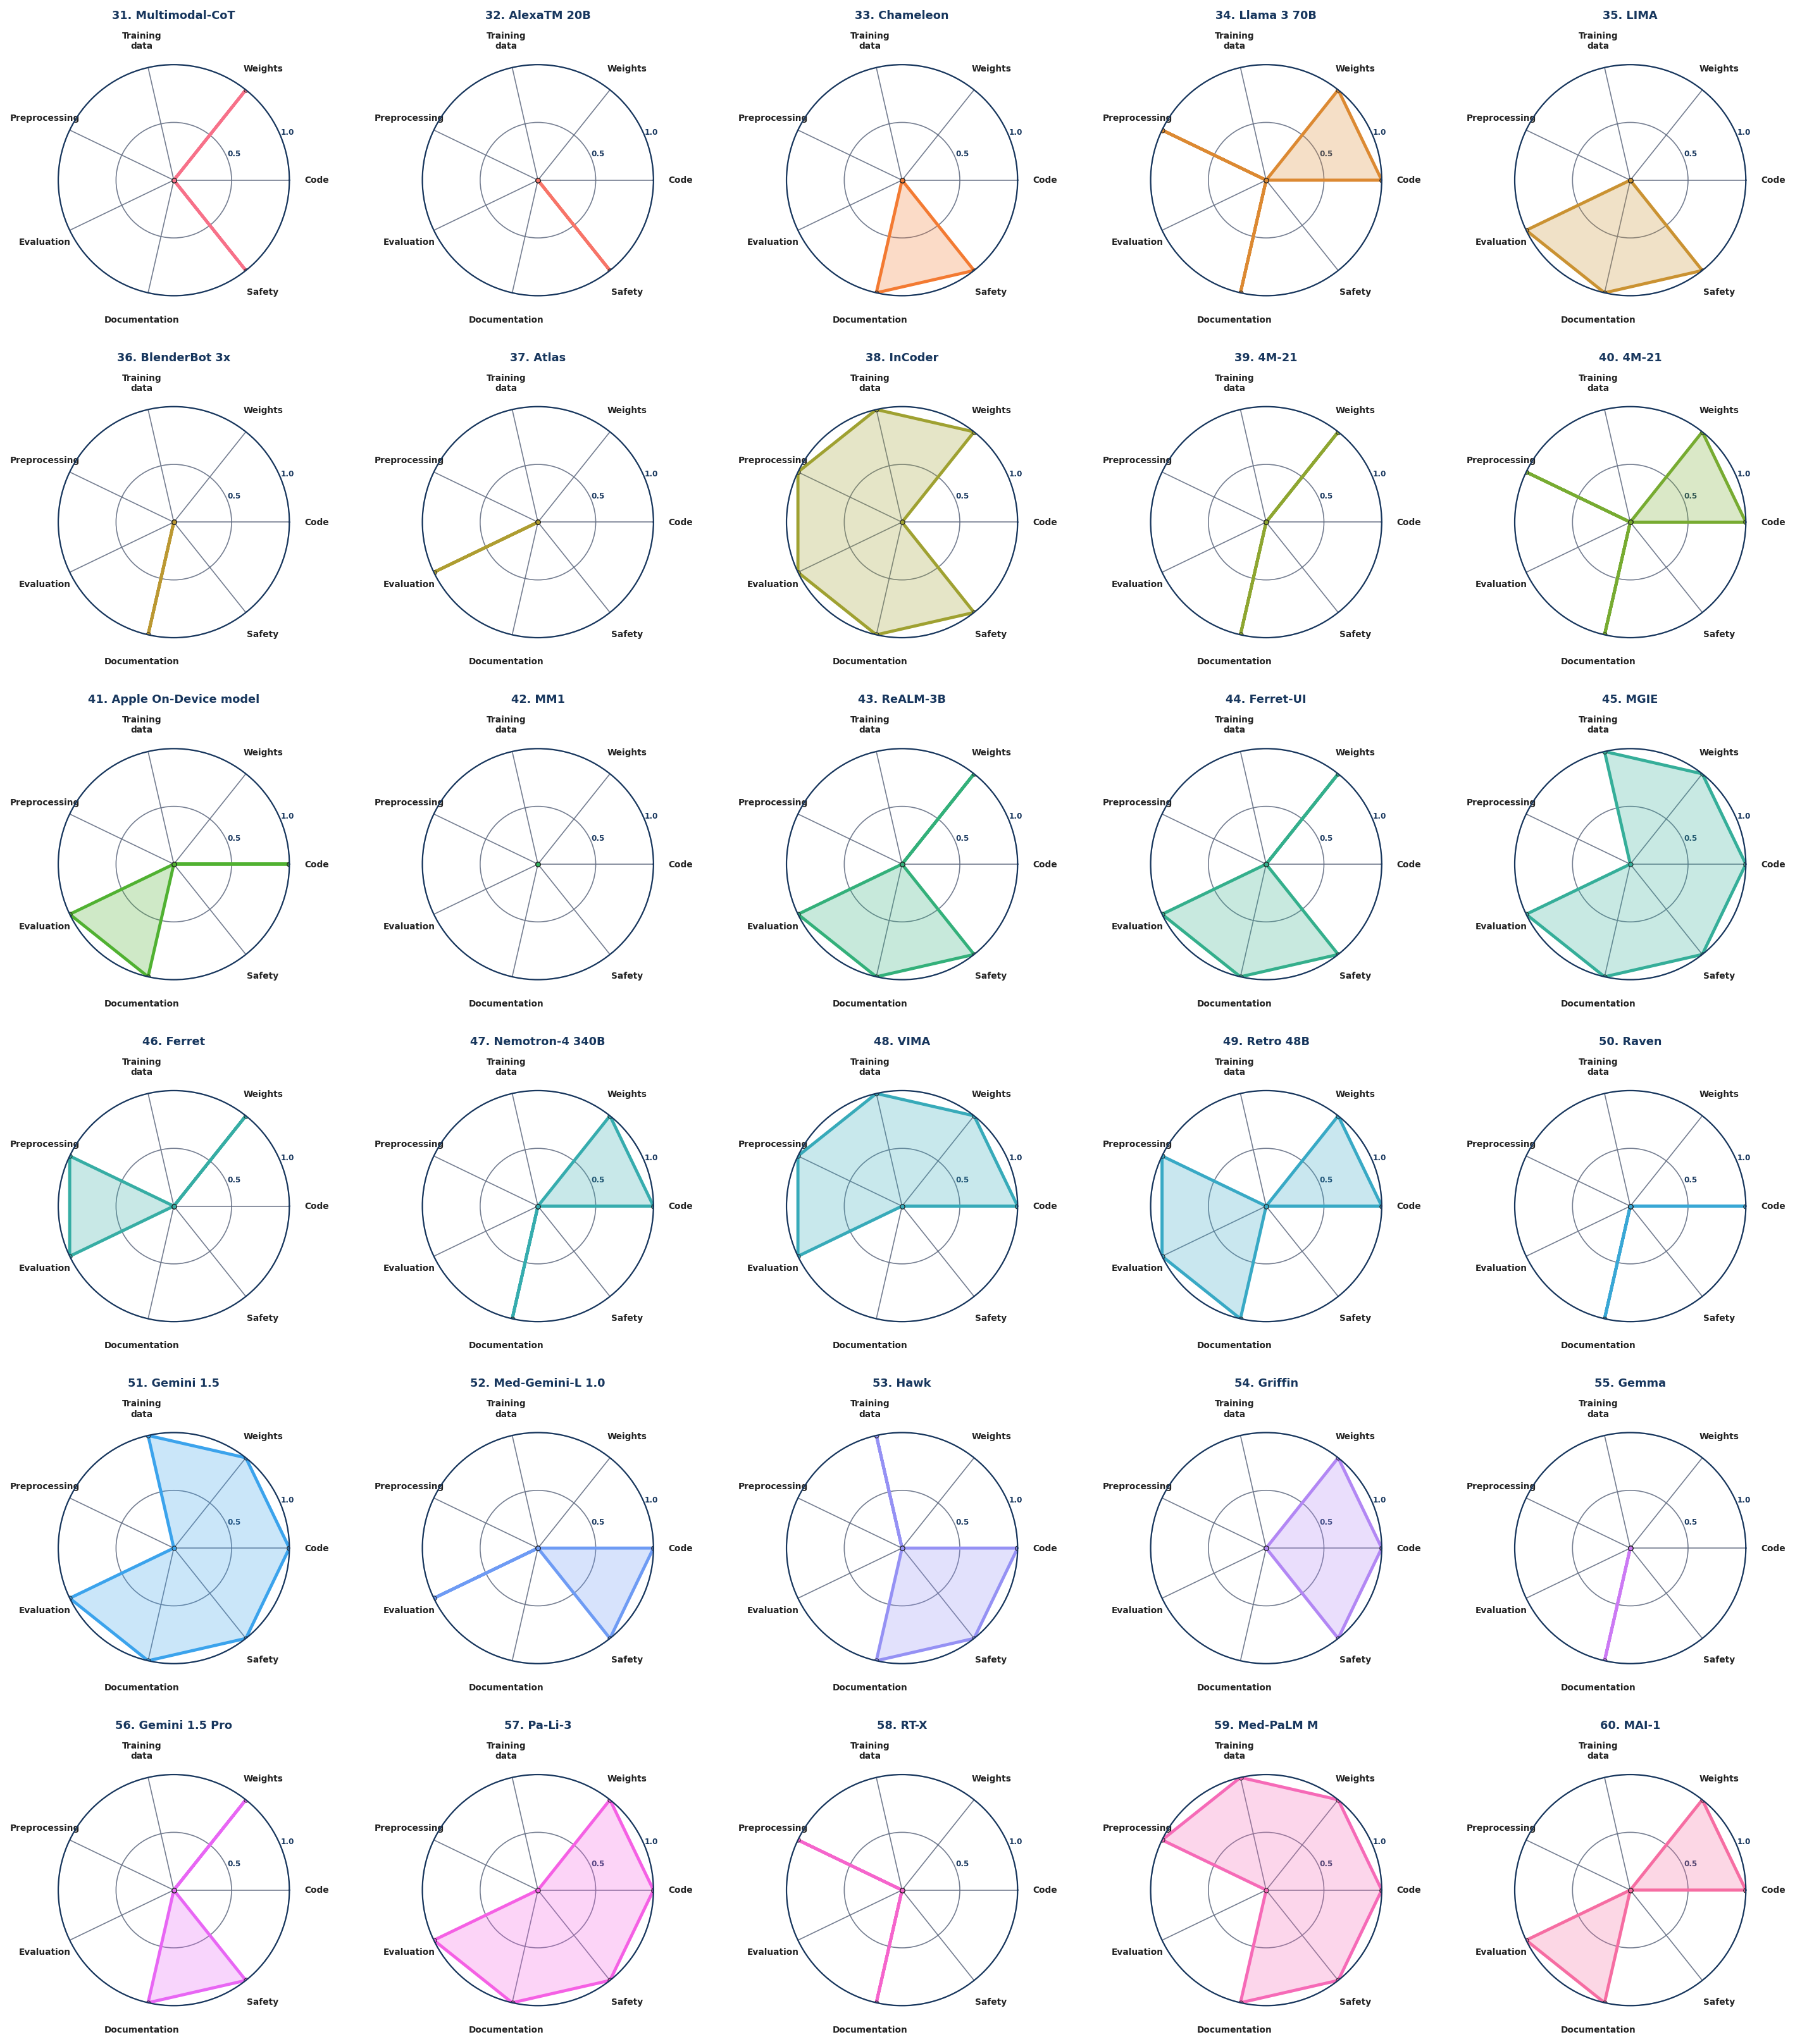

Saved: Figure_12_radar_group_3_061-090.png and Figure_12_radar_group_3_061-090.svg


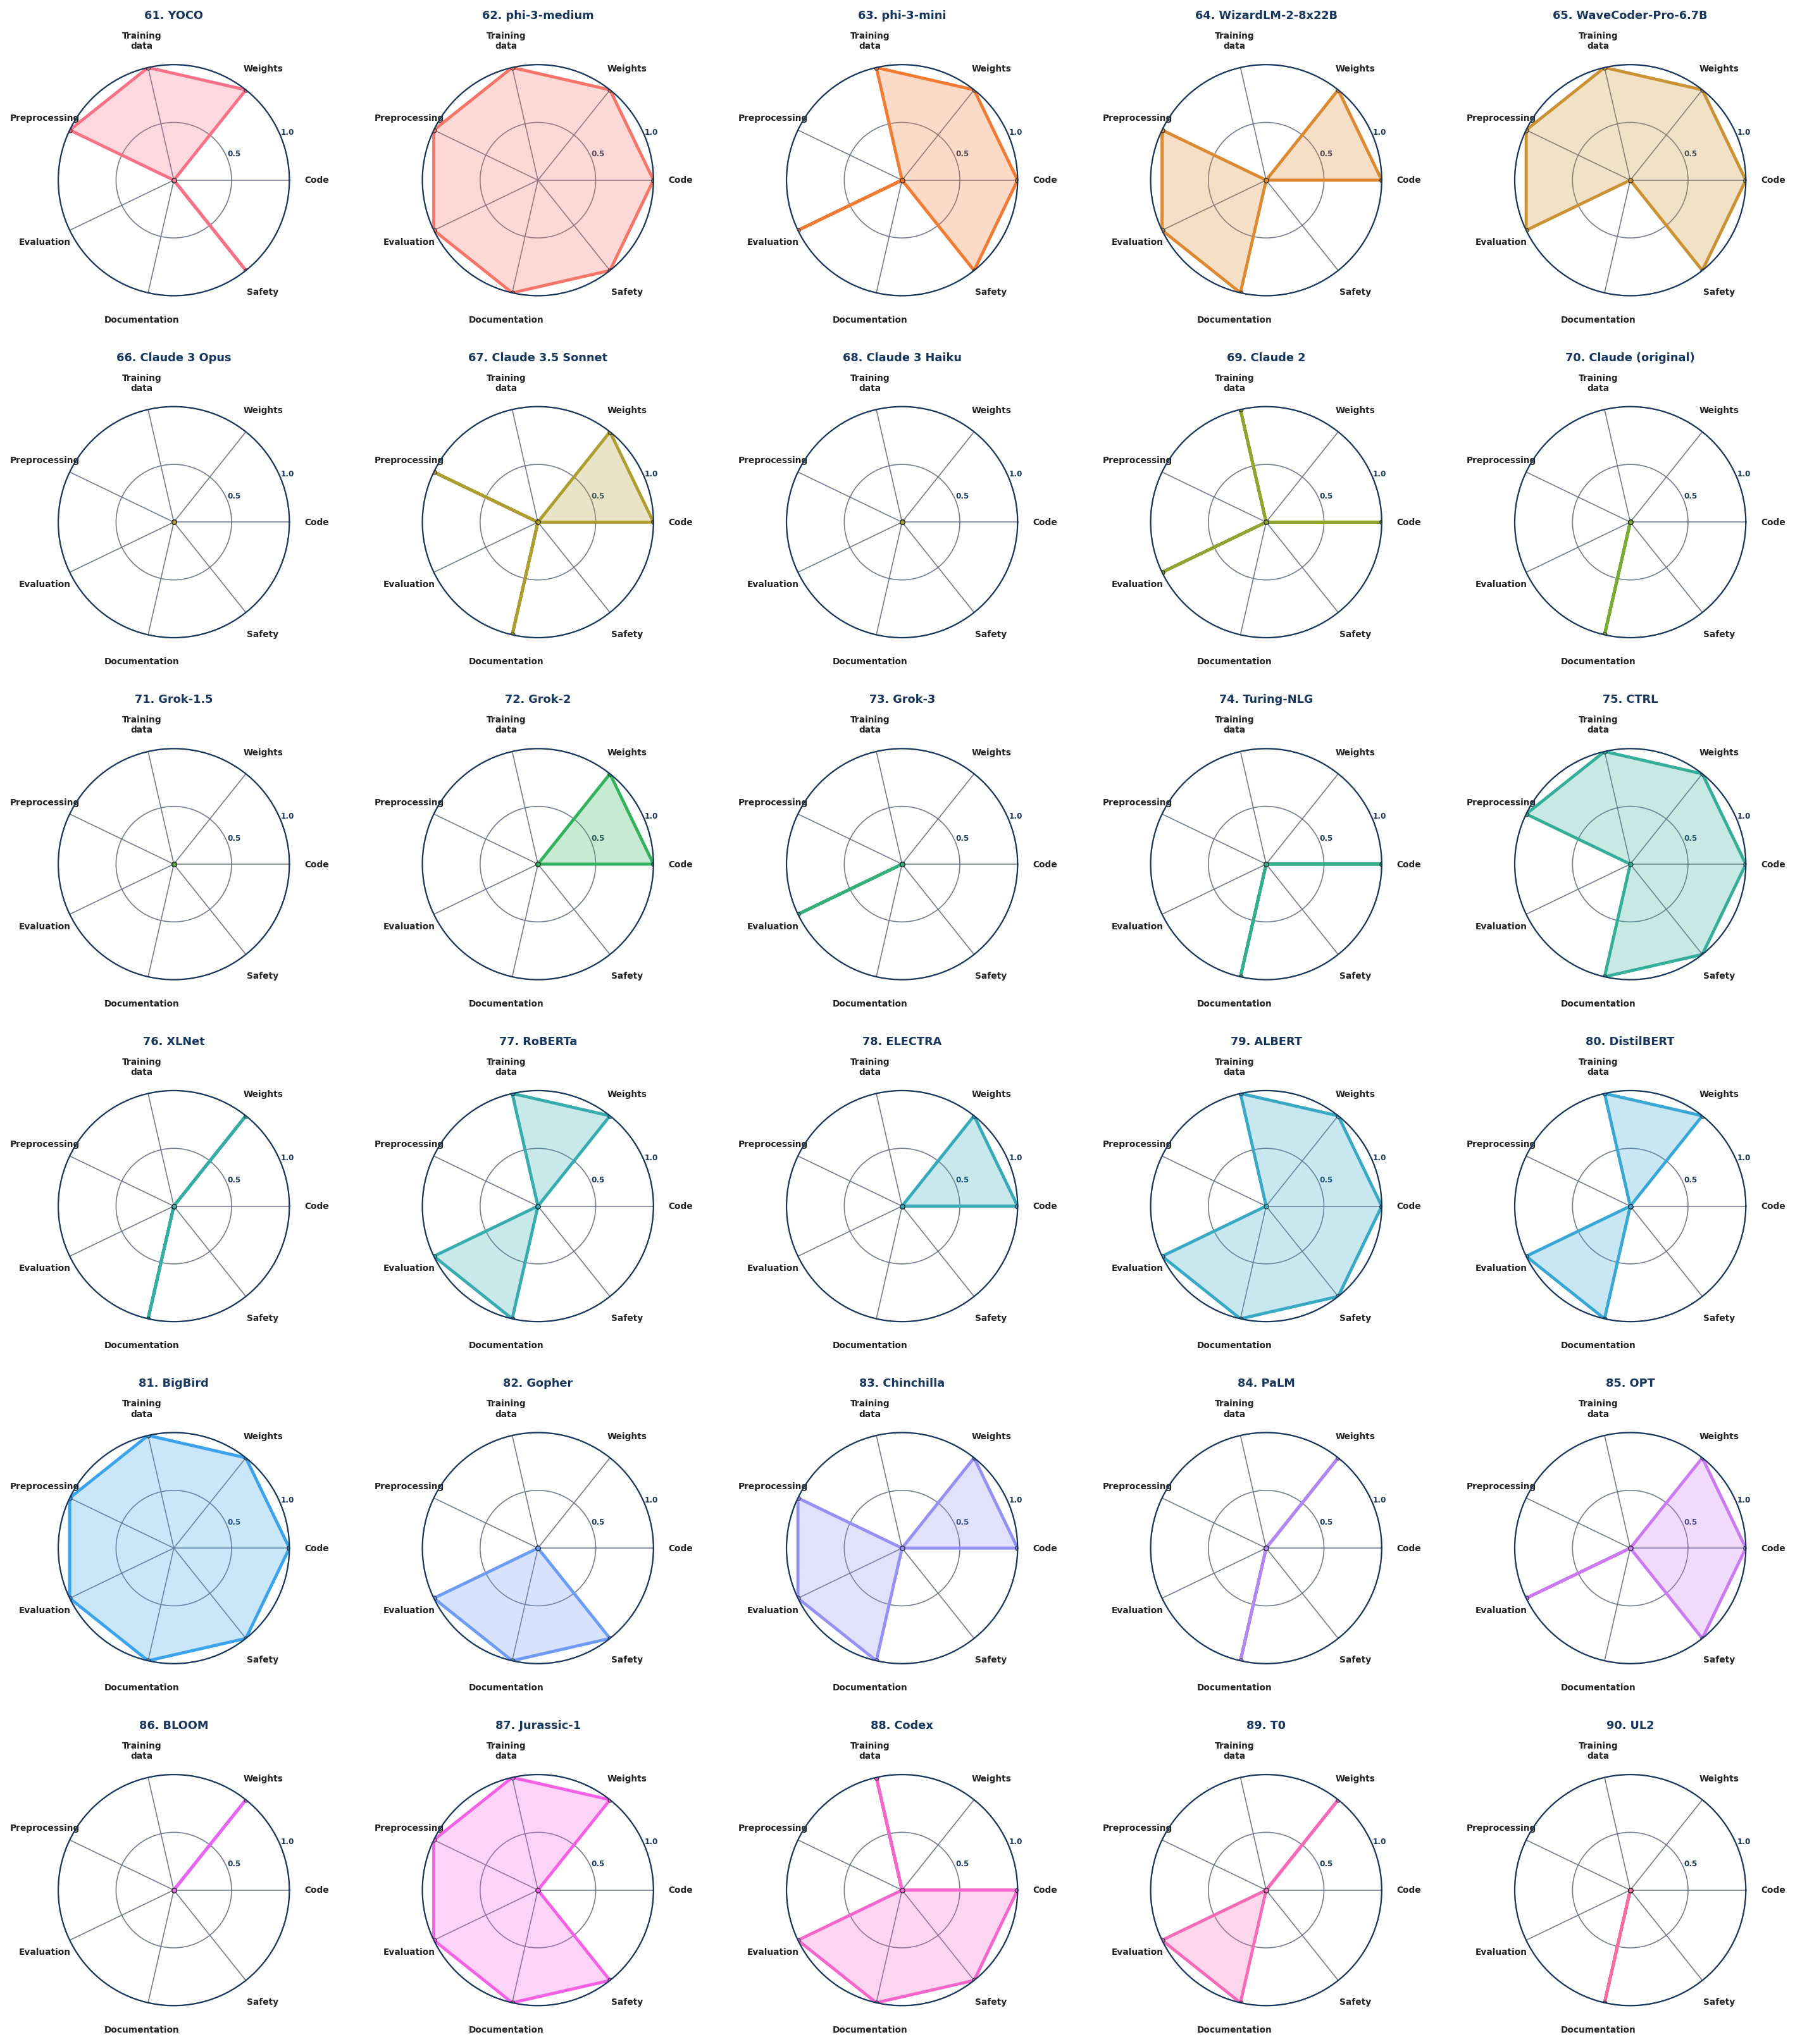

Saved: Figure_12_radar_group_4_091-120.png and Figure_12_radar_group_4_091-120.svg


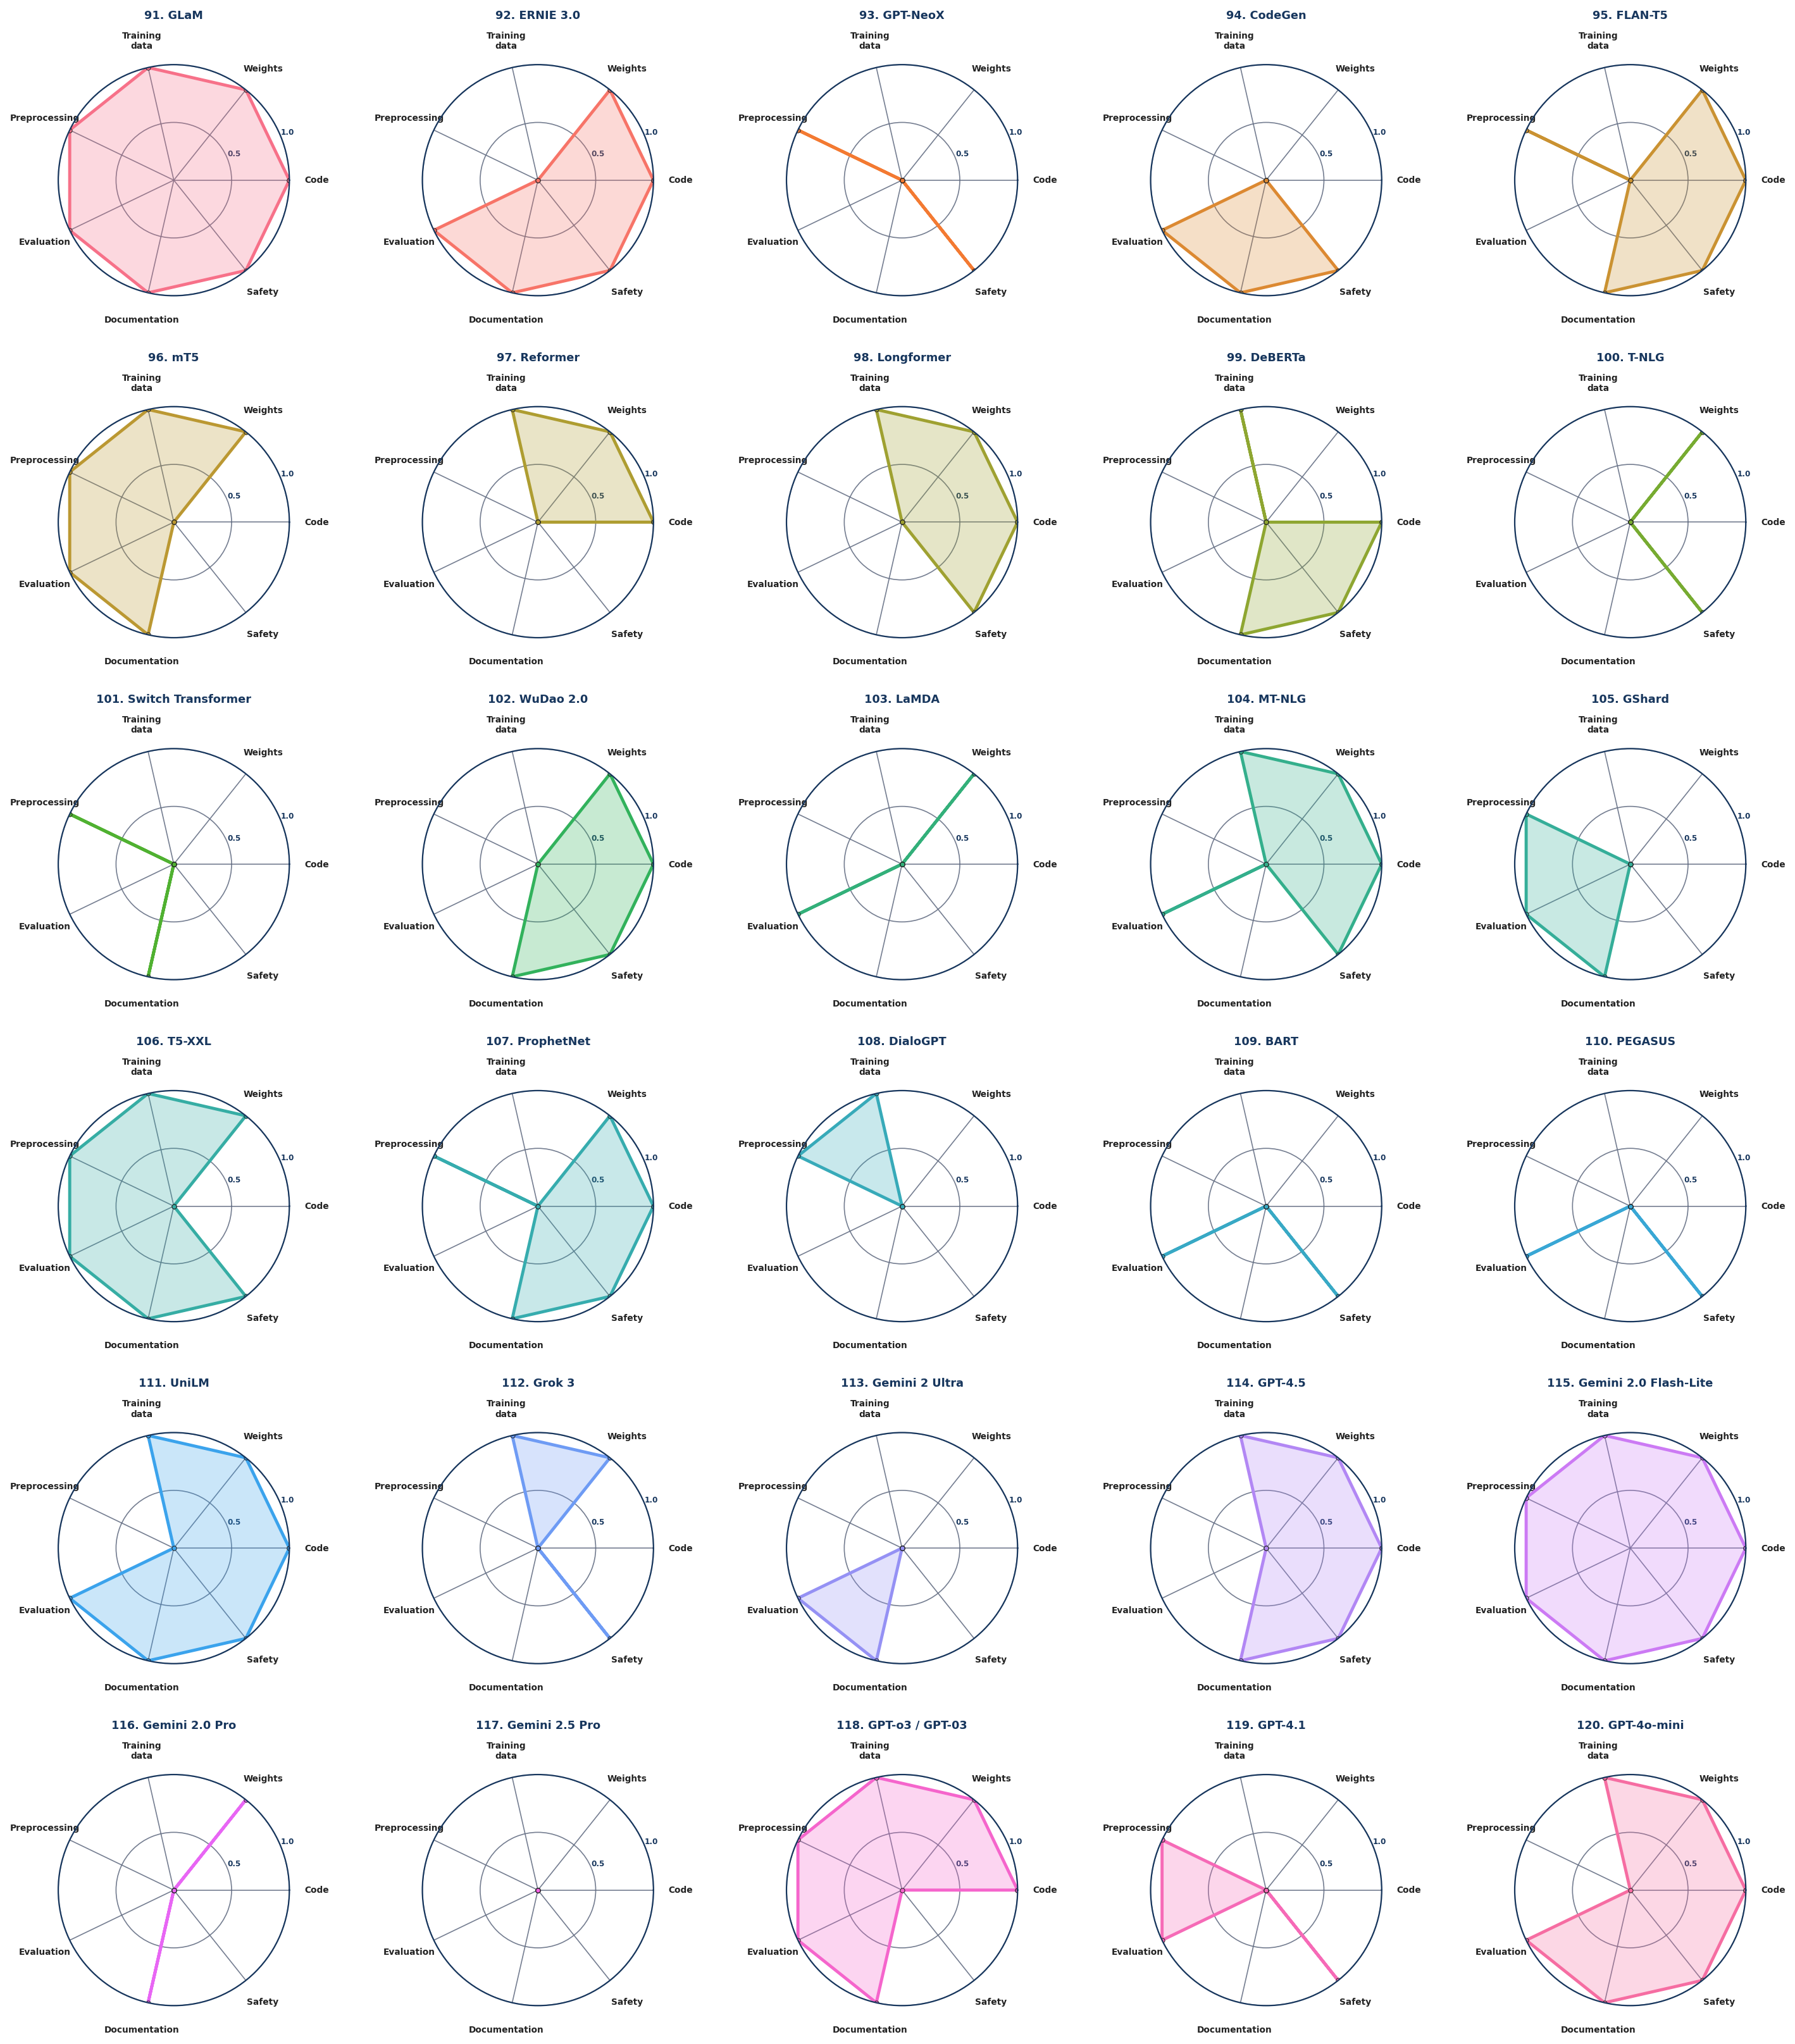

Saved: Figure_12_radar_group_5_121-121.png and Figure_12_radar_group_5_121-121.svg


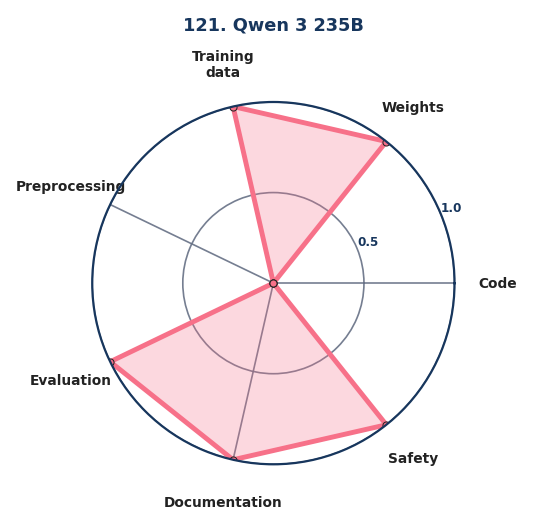

Saved: Figure_14a_CTS_TDDI_trends.png and Figure_14a_CTS_TDDI_trends.svg


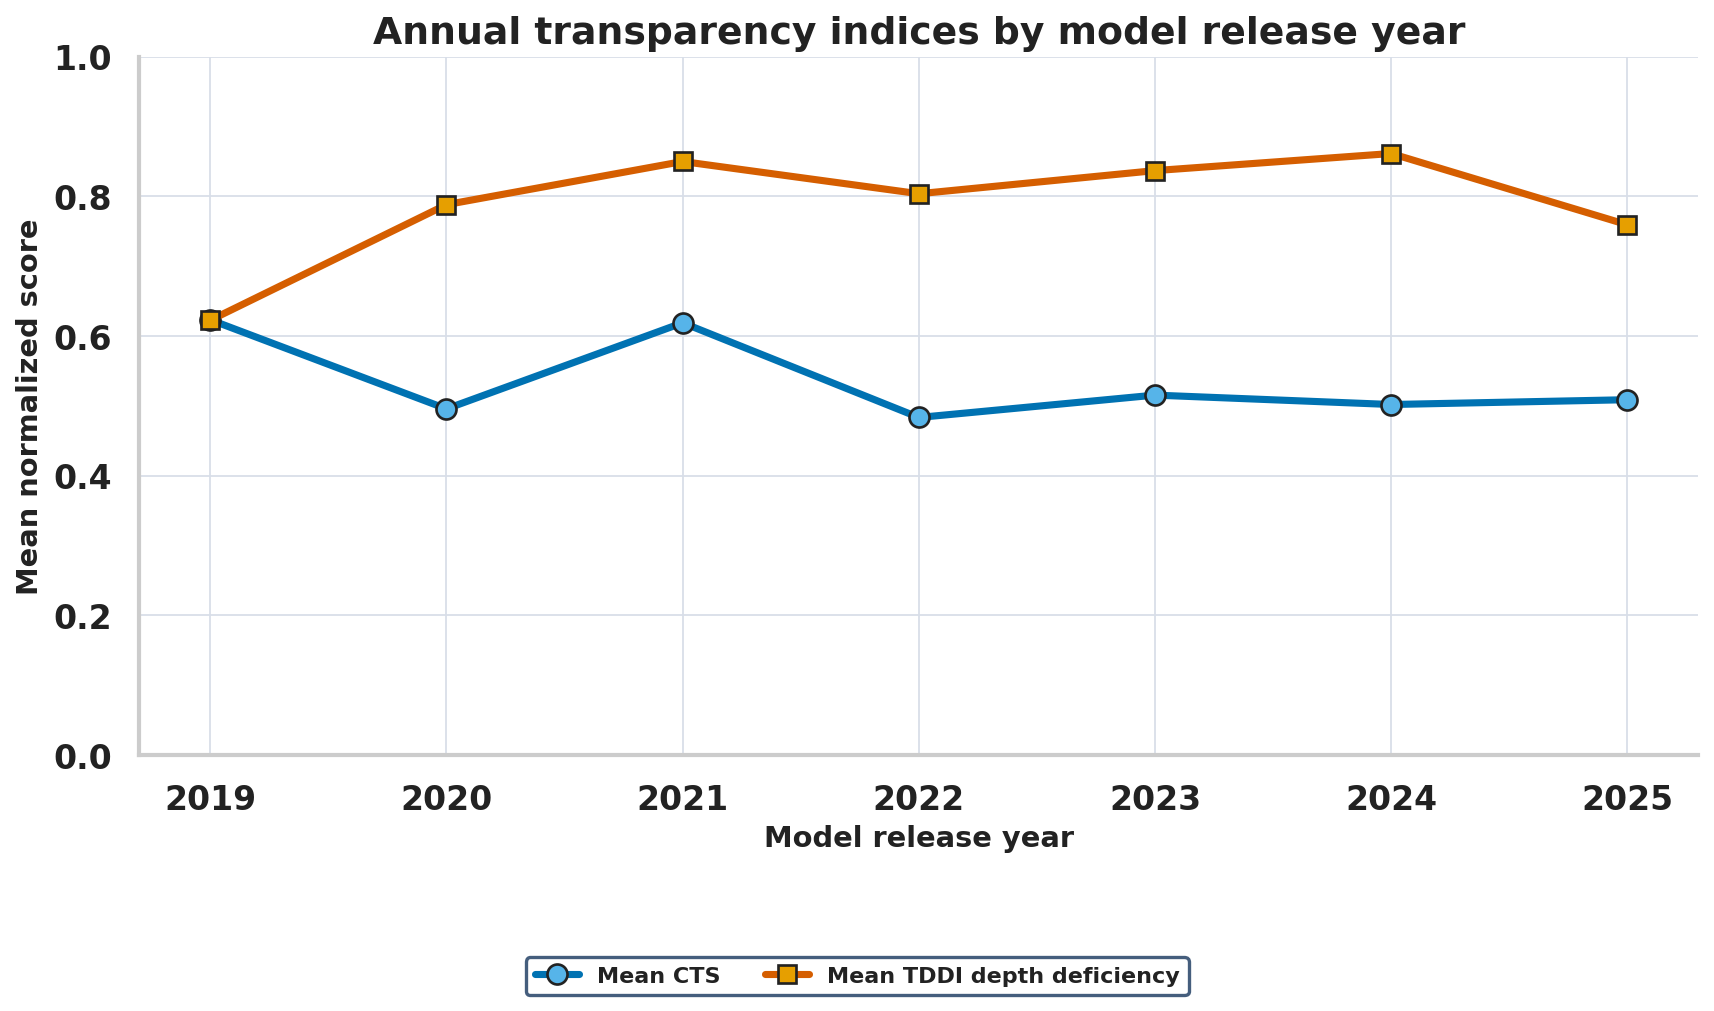


Done. PNG and SVG files were written beside the workbook: C:\Users\rs2672\Desktop\AI Open
Radar plots created for 121 model rows in 5 figures.
  Figure 12-1: 6 rows × 5 cols, models 1–30
  Figure 12-2: 6 rows × 5 cols, models 31–60
  Figure 12-3: 6 rows × 5 cols, models 61–90
  Figure 12-4: 6 rows × 5 cols, models 91–120
  Figure 12-5: 7 rows × 5 cols, models 121–121


In [7]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.font_manager import FontProperties

# Workbook path from the attached script. Use a raw string for Windows paths.
WORKBOOK_PATH = Path(r"C:\Users\rs2672\Desktop\AI Open\FinalWorkbook.xlsx")

# High-contrast sRGB/RGB colors.
COLORS = {
    "blue": "#0072B2", "sky": "#56B4E9", "orange": "#E69F00",
    "vermillion": "#D55E00", "green": "#009E73", "purple": "#7A3E9D",
    "pink": "#CC79A7", "yellow": "#F0E442", "navy": "#17365D",
    "black": "#222222", "gray": "#667085", "lightgray": "#D8DEE8"
}
CATEGORY_COLORS = {
    "open-source": COLORS["green"], "open source": COLORS["green"],
    "open-weight": COLORS["orange"], "open weight": COLORS["orange"],
    "proprietary": COLORS["vermillion"], "hybrid": COLORS["purple"],
    "unclassified": COLORS["gray"]
}

if not WORKBOOK_PATH.exists():
    raise FileNotFoundError(
        f"Workbook not found: {WORKBOOK_PATH}\n"
        "Update WORKBOOK_PATH to the correct workbook location."
    )

OUT_DIR = WORKBOOK_PATH.parent  # PNG and SVG figures go beside the workbook.

# ============================================================
#  Auto-detect the correct worksheet
# ============================================================
xl = pd.ExcelFile(WORKBOOK_PATH, engine="openpyxl")
print("Workbook sheets:", xl.sheet_names)

preferred_names = [
    "Audit Data",
    "Audit_Data",
    "AuditData",
    "Audit",
    "Sheet1",
]

SHEET = None
for name in preferred_names:
    if name in xl.sheet_names:
        SHEET = name
        break

if SHEET is None:
    audit_like = [s for s in xl.sheet_names if "audit" in s.lower()]
    if audit_like:
        SHEET = audit_like[0]

if SHEET is None:
    SHEET = xl.sheet_names[0]
    print(f"No audit-like sheet name found. Falling back to first sheet: '{SHEET}'")

print(f"Using sheet: '{SHEET}'")

df = pd.read_excel(WORKBOOK_PATH, sheet_name=SHEET, engine="openpyxl")
df.columns = [str(c).strip() for c in df.columns]

# ============================================================
#  Column mapping
# ============================================================
COL_ID = "List No."
COL_MODEL = "Model name"
COL_YEAR = "Release year"
COL_CATEGORY = "Category"

CTS_COMPONENTS = [
    "Code present", "Weights present", "Training data present",
    "Preprocessing disclosed", "Evaluation protocol disclosed",
    "Documentation adequate", "Alignment/safety disclosed"
]
TDDI_DEPTH_COMPONENTS = [
    "Source spec depth", "Preprocessing depth", "Data license depth",
    "Language/domain depth", "Synthetic/organic ratio depth"
]


def find_column(df, base_name):
    """Return the first column matching base_name exactly or with a suffix like (mock)."""
    if base_name in df.columns:
        return base_name
    pattern = base_name.lower()
    for c in df.columns:
        if c.lower().startswith(pattern):
            return c
    return None


COL_ID_R       = find_column(df, COL_ID)
COL_MODEL_R    = find_column(df, COL_MODEL)
COL_YEAR_R     = find_column(df, COL_YEAR)
COL_CATEGORY_R = find_column(df, COL_CATEGORY)

CTS_R  = [find_column(df, c) for c in CTS_COMPONENTS]
TDDI_R = [find_column(df, c) for c in TDDI_DEPTH_COMPONENTS]

if COL_MODEL_R is None or COL_YEAR_R is None or any(c is None for c in CTS_R) or any(c is None for c in TDDI_R):
    print("\nAvailable columns in the sheet:")
    for c in df.columns:
        print(f"  - {c}")
    raise ValueError(
        "Could not map all required columns. "
        "See the list above and adjust COL_* / *_COMPONENTS in the script."
    )

print(f"Resolved columns: model='{COL_MODEL_R}', year='{COL_YEAR_R}', "
      f"category='{COL_CATEGORY_R}', id='{COL_ID_R}'")

for col in [COL_YEAR_R] + CTS_R + TDDI_R:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df[COL_MODEL_R] = df[COL_MODEL_R].astype("string").str.strip()
df = df[df[COL_MODEL_R].notna() & (df[COL_MODEL_R] != "")].copy()

if COL_ID_R is not None:
    df[COL_ID_R] = pd.to_numeric(df[COL_ID_R], errors="coerce")
    df = df.sort_values(COL_ID_R, kind="stable", na_position="last")
else:
    COL_ID_R = "List No."
    df[COL_ID_R] = np.arange(1, len(df) + 1)

df["CTS_plot"] = df[CTS_R].mean(axis=1, skipna=True)
df["TDDI_deficiency_plot"] = (1 - df[TDDI_R]).mean(axis=1, skipna=True)
RS_COMPONENTS = [CTS_R[0], CTS_R[1], CTS_R[2], CTS_R[4]]
df["RS_plot"] = df[RS_COMPONENTS].mean(axis=1, skipna=True)

# ============================================================
#  Global style
# ============================================================
sns.set_theme(style="whitegrid", context="talk", font_scale=0.9)
plt.rcParams.update({
    "figure.dpi": 160, "savefig.dpi": 600,
    "font.family": "DejaVu Sans", "font.weight": "bold",
    "axes.titleweight": "bold", "axes.labelweight": "bold",
    "axes.labelcolor": COLORS["black"], "text.color": COLORS["black"],
    "xtick.color": COLORS["black"], "ytick.color": COLORS["black"],
    "svg.fonttype": "none", "axes.spines.top": False,
    "axes.spines.right": False, "grid.color": COLORS["lightgray"],
    "grid.linewidth": 0.8
})
BOLD_LEGEND = FontProperties(weight="bold", size=10)


def save_figure(fig, stem):
    """Save a figure as a 600-dpi PNG and vector SVG beside the workbook."""
    png_path = OUT_DIR / f"{stem}.png"
    svg_path = OUT_DIR / f"{stem}.svg"
    fig.savefig(png_path, dpi=600, bbox_inches="tight", facecolor="white")
    fig.savefig(svg_path, format="svg", bbox_inches="tight", facecolor="white")
    print(f"Saved: {png_path.name} and {svg_path.name}")
    plt.show()
    plt.close(fig)


def bold_ticks(ax, size=None):
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight("bold")
        if size is not None:
            label.set_fontsize(size)


# ============================================================
#  Figure 5: model counts by release year
# ============================================================
year_df = df.dropna(subset=[COL_YEAR_R]).copy()
year_df[COL_YEAR_R] = year_df[COL_YEAR_R].astype(int)
year_counts = year_df.groupby(COL_YEAR_R)[COL_MODEL_R].count().sort_index()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(year_counts.index.astype(str), year_counts.values,
              color=COLORS["blue"], edgecolor=COLORS["black"], linewidth=1.1)
ax.bar_label(bars, padding=4, fontsize=11, fontweight="bold", color=COLORS["black"])
ax.set(title="Model inventory by release year", xlabel="Release year",
       ylabel="Number of listed entries")
ax.set_ylim(0, max(year_counts.values, default=1) * 1.2)
ax.title.set_fontsize(17); ax.xaxis.label.set_fontsize(13); ax.yaxis.label.set_fontsize(13)
bold_ticks(ax)
fig.tight_layout()
save_figure(fig, "Figure_05_model_counts")

# ============================================================
#  Figure 10: CTS distribution
# ============================================================
cts = df["CTS_plot"].dropna()
fig, ax = plt.subplots(figsize=(10, 6))
bins = np.linspace(0, 1, 11)
ax.hist(cts, bins=bins, color=COLORS["sky"], edgecolor=COLORS["navy"], linewidth=1.4)
mean_line = ax.axvline(cts.mean(), color=COLORS["vermillion"], linestyle="--",
                       linewidth=3, label=f"Mean = {cts.mean():.2f}")
median_line = ax.axvline(cts.median(), color=COLORS["navy"], linestyle=":",
                         linewidth=3, label=f"Median = {cts.median():.2f}")
ax.set(title=f"Distribution of composite transparency scores (n={len(cts)})",
       xlabel="CTS (0–1)", ylabel="Number of models", xlim=(0, 1))
ax.title.set_fontsize(17); ax.xaxis.label.set_fontsize(13); ax.yaxis.label.set_fontsize(13)
bold_ticks(ax)
fig.legend(handles=[mean_line, median_line], loc="lower center", ncol=2,
           bbox_to_anchor=(0.5, 0.01), frameon=True, prop=BOLD_LEGEND,
           edgecolor=COLORS["navy"])
fig.tight_layout(rect=[0, 0.12, 1, 1])
save_figure(fig, "Figure_10_CTS_distribution")

# ============================================================
#  Figure 11: category means and release-year trend
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
legend_handles = []
if COL_CATEGORY_R is not None and COL_CATEGORY_R in df.columns:
    cat = df.dropna(subset=[COL_CATEGORY_R, "CTS_plot"]).copy()
    cat["_cat_norm"] = cat[COL_CATEGORY_R].astype(str).str.strip().str.lower()
    present = list(cat["_cat_norm"].dropna().unique())
    category_order = [x for x in ["open-source", "open-weight", "proprietary", "hybrid", "unclassified"] if x in present]
    means = cat.groupby("_cat_norm")["CTS_plot"].mean().reindex(category_order).dropna()
    bar_colors = [CATEGORY_COLORS.get(x, COLORS["gray"]) for x in means.index]
    bars = axes[0].bar(means.index, means.values, color=bar_colors,
                       edgecolor=COLORS["black"], linewidth=1.0)
    axes[0].bar_label(bars, fmt="%.2f", padding=3, fontsize=9, fontweight="bold")
    axes[0].set(xlabel="Disclosure category", ylabel="Mean CTS",
                ylim=(0, 1), title="Mean CTS by category")
    axes[0].tick_params(axis="x", rotation=20)
    legend_handles = [Patch(facecolor=CATEGORY_COLORS.get(x, COLORS["gray"]),
                            edgecolor=COLORS["black"], label=x.replace("-", " ").title())
                      for x in means.index]
else:
    axes[0].text(.5, .5, "Category column unavailable", ha="center", va="center",
                 transform=axes[0].transAxes, fontweight="bold")

trend = year_df.groupby(COL_YEAR_R, as_index=False).agg(
    mean_CTS=("CTS_plot", "mean"), n=(COL_MODEL_R, "count"))
axes[1].plot(trend[COL_YEAR_R], trend["mean_CTS"], marker="o",
             color=COLORS["purple"], markerfacecolor=COLORS["yellow"],
             markeredgecolor=COLORS["black"], markeredgewidth=1.3,
             linewidth=3, markersize=9)
for _, row in trend.iterrows():
    axes[1].annotate(f"n={int(row['n'])}", (row[COL_YEAR_R], row["mean_CTS"]),
                     xytext=(0, 10), textcoords="offset points", ha="center",
                     fontsize=9, fontweight="bold", color=COLORS["navy"])
axes[1].set(title="Mean CTS by model release year", xlabel="Release year",
            ylabel="Mean CTS", ylim=(0, 1))
for ax in axes:
    ax.title.set_fontsize(15); ax.xaxis.label.set_fontsize(12); ax.yaxis.label.set_fontsize(12)
    bold_ticks(ax)
if legend_handles:
    fig.legend(handles=legend_handles, loc="lower center", ncol=min(4, len(legend_handles)),
               bbox_to_anchor=(0.5, 0.01), frameon=True, prop=BOLD_LEGEND,
               edgecolor=COLORS["navy"])
fig.tight_layout(rect=[0, 0.13, 1, 1])
save_figure(fig, "Figure_11_category_and_year_trends")

# ============================================================
#  Figure 12: radar figures
#   - Figures 1–3: 6 rows × 5 cols = 30 panels each (models 1–90)
#   - Figure 4:    7 rows × 5 cols = 35 slots, 31 filled (models 91–121)
#  Each panel has the model name as its title.
# ============================================================
RADAR_LABELS = ["Code", "Weights", "Training\ndata", "Preprocessing",
                "Evaluation", "Documentation", "Safety"]
theta_base = np.linspace(0, 2 * np.pi, len(CTS_R), endpoint=False)
theta = np.r_[theta_base, theta_base[0]]

COLS = 5
# Build list of (n_rows, slice_start, slice_end) per figure.
total = len(df)
radar_layout = []
start = 0
while start < total:
    remaining = total - start
    if remaining >= 30:
        n_rows = 6
        chunk_size = 30
    else:
        # Last figure: 7 rows × 5 cols = 35 slots (fits 31 panels comfortably)
        n_rows = 7
        chunk_size = remaining
    radar_layout.append((n_rows, start, start + chunk_size))
    start += chunk_size

for group_number, (n_rows, start, end) in enumerate(radar_layout, start=1):
    group = df.iloc[start:end].copy()

    fig, axs = plt.subplots(n_rows, COLS, figsize=(18, n_rows * 3.4),
                            subplot_kw={"polar": True})
    axs = axs.flatten()
    radar_colors = sns.color_palette("husl", n_colors=max(len(group), 1))

    for i, (_, row) in enumerate(group.iterrows()):
        ax = axs[i]
        vals = pd.to_numeric(row[CTS_R], errors="coerce").to_numpy(dtype=float)
        closed_vals = np.r_[vals, vals[0]]
        color = radar_colors[i]
        ax.plot(theta, closed_vals, color=color, linewidth=2.2,
                marker="o", markersize=3.2, markeredgecolor=COLORS["black"],
                markeredgewidth=.45)
        if np.isfinite(vals).all():
            ax.fill(theta, closed_vals, color=color, alpha=.27)
        ax.set_xticks(theta_base)
        ax.set_xticklabels(RADAR_LABELS, fontsize=6.2, fontweight="bold",
                           color=COLORS["black"])
        ax.set_ylim(0, 1)
        ax.set_yticks([0.5, 1.0])
        ax.set_yticklabels(["0.5", "1.0"], fontsize=5.4,
                           fontweight="bold", color=COLORS["navy"])
        # Model name as panel title
        model_id = row[COL_ID_R]
        id_text = str(int(model_id)) if pd.notna(model_id) else str(start + i + 1)
        ax.set_title(f"{id_text}. {row[COL_MODEL_R]}", fontsize=8.0,
                     fontweight="bold", color=COLORS["navy"], pad=9)
        ax.grid(color=COLORS["gray"], linewidth=.75, alpha=.9)
        ax.spines["polar"].set_color(COLORS["navy"])
        ax.spines["polar"].set_linewidth(1.0)

    for ax in axs[len(group):]:
        ax.set_visible(False)

    first_id = int(group[COL_ID_R].iloc[0]) if pd.notna(group[COL_ID_R].iloc[0]) else start + 1
    last_id = int(group[COL_ID_R].iloc[-1]) if pd.notna(group[COL_ID_R].iloc[-1]) else end
    fig.subplots_adjust(top=.965, bottom=.025, left=.030, right=.970,
                        wspace=.42, hspace=.48)
    save_figure(fig, f"Figure_12_radar_group_{group_number}_{first_id:03d}-{last_id:03d}")

# ============================================================
#  Figure 14a: annual CTS and TDDI depth-deficiency indices
# ============================================================
trend14 = year_df.groupby(COL_YEAR_R, as_index=False).agg(
    mean_CTS=("CTS_plot", "mean"),
    mean_TDDI_deficiency=("TDDI_deficiency_plot", "mean")
)
fig, ax = plt.subplots(figsize=(11, 6.5))
line_cts, = ax.plot(trend14[COL_YEAR_R], trend14["mean_CTS"], marker="o",
                    color=COLORS["blue"], markerfacecolor=COLORS["sky"],
                    markeredgecolor=COLORS["black"], markeredgewidth=1.2,
                    linewidth=3.2, markersize=9, label="Mean CTS")
line_tddi, = ax.plot(trend14[COL_YEAR_R], trend14["mean_TDDI_deficiency"], marker="s",
                     color=COLORS["vermillion"], markerfacecolor=COLORS["orange"],
                     markeredgecolor=COLORS["black"], markeredgewidth=1.2,
                     linewidth=3.2, markersize=8, label="Mean TDDI depth deficiency")
ax.set(title="Annual transparency indices by model release year",
       xlabel="Model release year", ylabel="Mean normalized score", ylim=(0, 1))
ax.title.set_fontsize(17); ax.xaxis.label.set_fontsize(13); ax.yaxis.label.set_fontsize(13)
bold_ticks(ax)
fig.legend(handles=[line_cts, line_tddi], loc="lower center", ncol=2,
           bbox_to_anchor=(0.5, 0.01), frameon=True, prop=BOLD_LEGEND,
           edgecolor=COLORS["navy"])
fig.tight_layout(rect=[0, 0.12, 1, 1])
save_figure(fig, "Figure_14a_CTS_TDDI_trends")

print(f"\nDone. PNG and SVG files were written beside the workbook: {OUT_DIR}")
print(f"Radar plots created for {len(df)} model rows in {len(radar_layout)} figures.")
for idx, (n_rows, s, e) in enumerate(radar_layout, start=1):
    print(f"  Figure 12-{idx}: {n_rows} rows × {COLS} cols, models {s+1}–{e}")